##  What is Clustering?
Clustering is an **unsupervised learning** technique used to group similar data points together based on feature similarity.

The idea is simple:
> “Group data points such that points within a cluster are similar, and points across clusters are dissimilar.”

---

## What is K-Means?
**K-Means** is one of the simplest and most widely used clustering algorithms.  
It tries to partition the dataset into **K clusters**, where each cluster has a **centroid** (center point).

---

## How It Works (Step-by-Step)
1. Choose the number of clusters, `K`.
2. Randomly initialize `K` centroids.
3. Assign each point to the nearest centroid.
4. Update each centroid as the mean of points in its cluster.
5. Repeat steps 3–4 until centroids stop moving (convergence).

---

## Objective Function
K-Means minimizes the **Within-Cluster Sum of Squares (WCSS)**, also called **Inertia**:

$$
J = \sum_{i=1}^{k} \sum_{x_j \in C_i} || x_j - \mu_i ||^2
$$

Where:
$$
- ( C_i ): Cluster i  
- ( mu_i ): Centroid of cluster i  
- ( x_j ): Data point in cluster i  
$$

---

##  Why Use K-Means?
- Fast and efficient for large datasets  
- Easy to interpret  
- Works well when clusters are spherical and well-separated  

---

## Limitations
- Need to specify `K` in advance  
- Sensitive to centroid initialization  
- Struggles with non-spherical clusters or outliers  

---

## Real-Life Applications
- Customer segmentation in marketing  
- Image compression  
- Document clustering  
- Anomaly detection


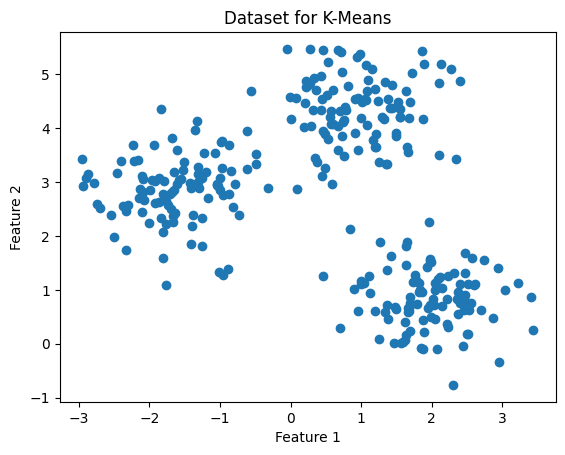

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# create toy dataset
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.60,
    random_state=0
)

# visualize
plt.scatter(X[:, 0], X[:, 1])
plt.title("Dataset for K-Means")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [3]:
# Randomly select k data points as initial centroids
def initialize_centroids(X, k, random_state=None):
    if random_state:
        np.random.seed(random_state)
    random_indices = np.random.choice(len(X), size=k, replace=False)
    centroids = X[random_indices]
    return centroids

Initial Centroids:
 [[-2.21078549  3.38885677]
 [ 0.55952936  4.2140066 ]
 [ 0.67047877  4.04094275]]


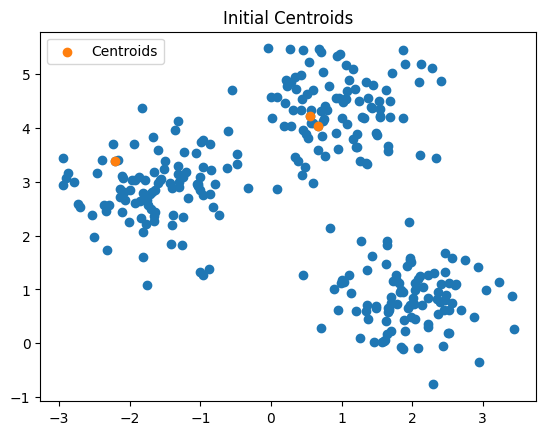

In [19]:
# Demo
centroids = initialize_centroids(X, k=3, random_state=42)
print("Initial Centroids:\n", centroids)

plt.scatter(X[:, 0], X[:, 1])
plt.scatter(centroids[:, 0], centroids[:, 1],label='Centroids')
plt.legend()
plt.title("Initial Centroids")
plt.show()

In [20]:
# Compute Euclidean distance from each point to each centroid
def compute_distances(X, centroids):
    distances = np.zeros((X.shape[0], len(centroids)))
    for i, c in enumerate(centroids):
        distances[:, i] = np.linalg.norm(X - c, axis=1)
    return distances

In [21]:
# Demo
distances = compute_distances(X, centroids)
print("Shape of Distance Matrix:", distances.shape)
print("First 5 distance rows:\n", distances[:5])

Shape of Distance Matrix: (300, 3)
First 5 distance rows:
 [[3.07878269 0.77119008 0.96390198]
 [5.06997699 4.27980342 4.08515736]
 [3.77523609 0.8884046  0.83310862]
 [0.7248661  2.44179113 2.46388884]
 [1.24996291 2.9511468  2.92745304]]


In [22]:
# Assign each sample to the nearest centroid.
def assign_clusters(distances):
    return np.argmin(distances, axis=1)

# Demo
labels = assign_clusters(distances)
print("Assigned Cluster Labels (first 10):", labels[:10])

Assigned Cluster Labels (first 10): [1 2 2 0 0 0 2 1 0 1]


In [23]:
# Compute new centroids as the mean of all points in each cluster
def update_centroids(X, labels, k):
    new_centroids = np.zeros((k, X.shape[1]))
    for i in range(k):
        new_centroids[i] = X[labels == i].mean(axis=0)
    return new_centroids

In [24]:
# Demo
new_centroids = update_centroids(X, labels, k=3)
print("Updated Centroids:\n", new_centroids)

Updated Centroids:
 [[-1.6848724   2.83057985]
 [ 0.65261972  4.74725333]
 [ 1.65204456  1.90677937]]


In [25]:
# Compute Within-Cluster Sum of Squares (WCSS)
def compute_inertia(X, centroids, labels):
    total_variance = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        total_variance += np.sum((cluster_points - centroids[i]) ** 2)
    return total_variance

# Demo
inertia = compute_inertia(X, new_centroids, labels)
print("Current Inertia (WCSS):", inertia)

Current Inertia (WCSS): 547.6450933157978


In [26]:
def fit_kmeans(X, k, max_iters=100, random_state=None):
    centroids = initialize_centroids(X, k, random_state)
    for _ in range(max_iters):
        old_centroids = centroids.copy()
        distances = compute_distances(X, centroids)
        labels = assign_clusters(distances)
        centroids = update_centroids(X, labels, k)

        # Stop if centroids don't change
        if np.allclose(old_centroids, centroids):
            break
    inertia = compute_inertia(X, centroids, labels)
    return centroids, labels, inertia

# Demo
centroids_final, labels_final, inertia_final = fit_kmeans(X, k=3, random_state=42)
print("Final Centroids:\n", centroids_final)
print("Final Inertia:", inertia_final)

Final Centroids:
 [[-1.60811992  2.85881658]
 [ 0.95625704  4.37226546]
 [ 1.95159369  0.83467497]]
Final Inertia: 212.35550348922897


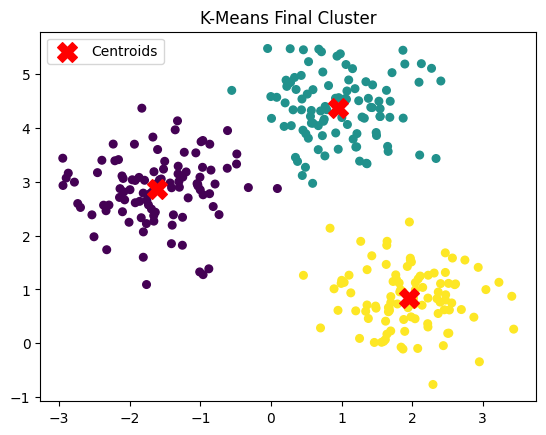

In [28]:
plt.scatter(X[:, 0], X[:, 1], c=labels_final, cmap='viridis', s=30)
plt.scatter(centroids_final[:, 0], centroids_final[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Final Cluster")
plt.legend()
plt.show()

In [29]:
from sklearn.cluster import KMeans

sk_kmeans = KMeans(n_clusters=3, random_state=42)
sk_kmeans.fit(X)

print("Sklearn Centroids:\n", sk_kmeans.cluster_centers_)
print("Scratch Centroids:\n", centroids_final)

Sklearn Centroids:
 [[ 0.95625704  4.37226546]
 [-1.60811992  2.85881658]
 [ 1.95159369  0.83467497]]
Scratch Centroids:
 [[-1.60811992  2.85881658]
 [ 0.95625704  4.37226546]
 [ 1.95159369  0.83467497]]
